In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
iris=load_iris()
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df=df.iloc[:,1:]

In [5]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm)
0,3.5,1.4,0.2
1,3.0,1.4,0.2
2,3.2,1.3,0.2
3,3.1,1.5,0.2
4,3.6,1.4,0.2


In [6]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder=LabelEncoder()
df['Species']=encoder.fit_transform(df['Species'])

In [9]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm),Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


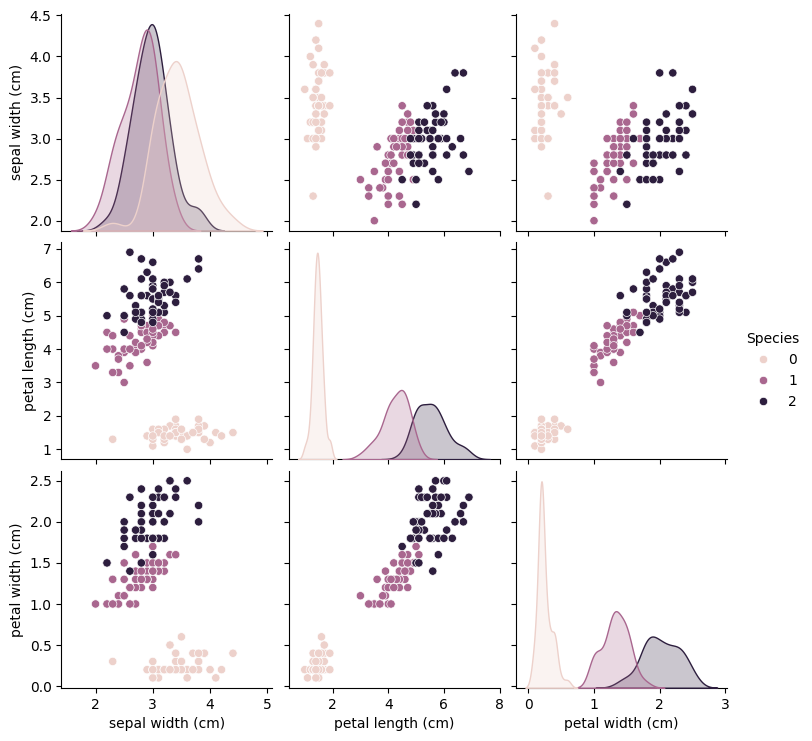

In [10]:
import seaborn as sns
sns.pairplot(df,hue='Species')

In [13]:
new_df=df[df['Species']!=0][['petal width (cm)','petal length (cm)','Species']]

In [14]:
new_df.head()

,petal width (cm),petal length (cm),Species
50,1.4,4.7,1
51,1.5,4.5,1
52,1.5,4.9,1
53,1.3,4.0,1
54,1.5,4.6,1


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [16]:
clf1=LogisticRegression()
clf2=KNeighborsClassifier()
clf3=RandomForestClassifier()

In [17]:
estimators=[('lr',clf1),('knn',clf2),('rf',clf3)]

In [18]:
for estimator in estimators:
    score=cross_val_score(estimator[1],new_df.iloc[:,:-1],new_df.iloc[:,-1],cv=5,scoring='accuracy')
    print(estimator[0],score.mean())

lr 0.95
knn 0.95
rf 0.95


In [19]:
from sklearn.ensemble import VotingClassifier


In [20]:
vc=VotingClassifier(estimators=estimators,voting='hard')
x=cross_val_score(vc,new_df.iloc[:,:-1],new_df.iloc[:,-1],cv=5,scoring='accuracy')
print('Voting Classifier:',x.mean())

Voting Classifier: 0.95


In [21]:
vc1=VotingClassifier(estimators=estimators,voting='soft')
y=cross_val_score(vc1,new_df.iloc[:,:-1],new_df.iloc[:,-1],cv=5,scoring='accuracy')
print('Voting Classifier:',y.mean())

Voting Classifier: 0.95


In [22]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc=VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x=cross_val_score(vc,X=new_df.iloc[:,:-1],y=new_df.iloc[:,-1],cv=5,scoring='accuracy')
            print('Voting Classifier:',x.mean(),'weights:',[i,j,k])

Voting Classifier: 0.95 weights: [1, 1, 1]
Voting Classifier: 0.9399999999999998 weights: [1, 1, 2]
Voting Classifier: 0.95 weights: [1, 1, 3]
Voting Classifier: 0.95 weights: [1, 2, 1]
Voting Classifier: 0.95 weights: [1, 2, 2]
Voting Classifier: 0.95 weights: [1, 2, 3]
Voting Classifier: 0.9399999999999998 weights: [1, 3, 1]
Voting Classifier: 0.95 weights: [1, 3, 2]
Voting Classifier: 0.95 weights: [1, 3, 3]
Voting Classifier: 0.95 weights: [2, 1, 1]
Voting Classifier: 0.95 weights: [2, 1, 2]
Voting Classifier: 0.95 weights: [2, 1, 3]
Voting Classifier: 0.95 weights: [2, 2, 1]
Voting Classifier: 0.95 weights: [2, 2, 2]
Voting Classifier: 0.95 weights: [2, 2, 3]
Voting Classifier: 0.95 weights: [2, 3, 1]
Voting Classifier: 0.95 weights: [2, 3, 2]
Voting Classifier: 0.95 weights: [2, 3, 3]
Voting Classifier: 0.95 weights: [3, 1, 1]
Voting Classifier: 0.95 weights: [3, 1, 2]
Voting Classifier: 0.95 weights: [3, 1, 3]
Voting Classifier: 0.95 weights: [3, 2, 1]
Voting Classifier: 0.95 we

In [23]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
X,y=make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,n_classes=2,random_state=42)
sv1=SVC(probability=True,kernel='poly',degree=1)
sv2=SVC(probability=True,kernel='poly',degree=2)    
sv3=SVC(probability=True,kernel='poly',degree=3)
sv4=SVC(probability=True,kernel='poly',degree=4)
sv5=SVC(probability=True,kernel='poly',degree=5)

In [24]:
estimators1=[('sv1',sv1),('sv2',sv2),('sv3',sv3),('sv4',sv4),('sv5',sv5)]
for estimator in estimators1:
    score=cross_val_score(estimator[1],X,y,cv=5,scoring='accuracy')
    print(estimator[0],score.mean())

sv1 0.8089999999999999
sv2 0.909
sv3 0.909
sv4 0.883
sv5 0.86


In [25]:
vc1=VotingClassifier(estimators=estimators,voting='soft')
y=cross_val_score(vc1,new_df.iloc[:,:-1],new_df.iloc[:,-1],cv=5,scoring='accuracy')
print('Voting Classifier:',y.mean())

Voting Classifier: 0.95
